

# **Submission for:**  Assignment 3   
**by** 
- Michael Berger, 318063864  
- Barack Samuni, 318299625

## **Course**: 65027 - Cloud Technologies and Big Data
## **Program:** Intelligent Systems  
## **Course coordinator:** Dr. Morose Boris



**The purpose of this Lab is to practice SPARK Feature Manipulations**

**Problem definition**:



## 1.  Read data from the file "dataFIFA.scv".


In [1]:
import numpy as np
import pandas as pd
import sklearn 
import matplotlib.pyplot as plt


import os
from datetime import datetime
import statistics as stat

import plotly.express as px
from plotly.subplots import make_subplots

%matplotlib inline

### Data exploration

In [2]:
fifa = pd.read_csv("data/dataFIFA.csv", index_col=0)
# Loaned From only has 6% non-nulls, so we drop it immediately
del fifa["Loaned From"]
fifa

,ID,Name,Age,Photo,Nationality,Flag,Overall,Potential,Club,Club Logo,...,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Release Clause
0,158023,L. Messi,31,https://cdn.sofifa.org/players/4/19/158023.png,Argentina,https://cdn.sofifa.org/flags/52.png,94,94,FC Barcelona,https://cdn.sofifa.org/teams/2/light/241.png,...,96.0,33.0,28.0,26.0,6.0,11.0,15.0,14.0,8.0,€226.5M
1,20801,Cristiano Ronaldo,33,https://cdn.sofifa.org/players/4/19/20801.png,Portugal,https://cdn.sofifa.org/flags/38.png,94,94,Juventus,https://cdn.sofifa.org/teams/2/light/45.png,...,95.0,28.0,31.0,23.0,7.0,11.0,15.0,14.0,11.0,€127.1M
2,190871,Neymar Jr,26,https://cdn.sofifa.org/players/4/19/190871.png,Brazil,https://cdn.sofifa.org/flags/54.png,92,93,Paris Saint-Germain,https://cdn.sofifa.org/teams/2/light/73.png,...,94.0,27.0,24.0,33.0,9.0,9.0,15.0,15.0,11.0,€228.1M
3,193080,De Gea,27,https://cdn.sofifa.org/players/4/19/193080.png,Spain,https://cdn.sofifa.org/flags/45.png,91,93,Manchester United,https://cdn.sofifa.org/teams/2/light/11.png,...,68.0,15.0,21.0,13.0,90.0,85.0,87.0,88.0,94.0,€138.6M
4,192985,K. De Bruyne,27,https://cdn.sofifa.org/players/4/19/192985.png,Belgium,https://cdn.sofifa.org/flags/7.png,91,92,Manchester City,https://cdn.sofifa.org/teams/2/light/10.png,...,88.0,68.0,58.0,51.0,15.0,13.0,5.0,10.0,13.0,€196.4M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18202,238813,J. Lundstram,19,https://cdn.sofifa.org/players/4/19/238813.png,England,https://cdn.sofifa.org/flags/14.png,47,65,Crewe Alexandra,https://cdn.sofifa.org/teams/2/light/121.png,...,45.0,40.0,48.0,47.0,10.0,13.0,7.0,8.0,9.0,€143K
18203,243165,N. Christoffersson,19,https://cdn.sofifa.org/players/4/19/243165.png,Sweden,https://cdn.sofifa.org/flags/46.png,47,63,Trelleborgs FF,https://cdn.sofifa.org/teams/2/light/703.png,...,42.0,22.0,15.0,19.0,10.0,9.0,9.0,5.0,12.0,€113K
18204,241638,B. Worman,16,https://cdn.sofifa.org/players/4/19/241638.png,England,https://cdn.sofifa.org/flags/14.png,47,67,Cambridge United,https://cdn.sofifa.org/teams/2/light/1944.png,...,41.0,32.0,13.0,11.0,6.0,5.0,10.0,6.0,13.0,€165K
18205,246268,D. Walker-Rice,17,https://cdn.sofifa.org/players/4/19/246268.png,England,https://cdn.sofifa.org/flags/14.png,47,66,Tranmere Rovers,https://cdn.sofifa.org/teams/2/light/15048.png,...,46.0,20.0,25.0,27.0,14.0,6.0,14.0,8.0,9.0,€143K


In [3]:
def summary(df: pd.DataFrame, by:int = 4, ascending:bool=False):
    """a neat summary of a dataframe

    Args:
        df (pd.DataFrame): A DataFrame to summarize
        by (int, optional): column number to sort by. Defaults to 4 (unique values). 
        ascending (bool, optional): whether to sort ascending. Defaults to False (descending).

    Returns:
        pd.DataFrame: a new DataFrame representing the summary of df
    """
   
    nonnans = df.shape[0] - df.isna().sum()
    nonnansPrc = (nonnans / df.shape[0] * 100)#.apply("{0:.2f}%".format)

    # prevent examples column from being all nans by sampling from subset where all columns are nonna.
    df_nona = df.dropna(axis=0)
    if df_nona.shape[0] < 1:
        sam = df.sample(1, random_state=42).squeeze()
    else:
        sam = df_nona.sample(1, random_state=42).squeeze()

    nanExamples = sam.isna().sum()/sam.shape[0]
    if (nanExamples>0.1):
        print(f"Warning! examples for {100 * nanExamples:.0f}% of columns are nans. \
              \nMaybe try dropping columns that have majority nan values...")  

    res = pd.DataFrame([sam.index, df.dtypes.astype(str), nonnans,
                        nonnansPrc, df.nunique(), sam.astype(str)]).transpose()
    if res.shape[0]> 20:
        pd.set_option('display.max_rows', res.shape[0])

    print(f"The Dataframe has: \n {df.shape[1]} columns overall \n {df.shape[0]} rows overall")
    cols = ["column name", "data type", 
            "non-null values", "non-null values %",
            "unique values", "example"]
    sym = '↑' if ascending else '↓'
    cols[by] = sym + cols[by] + sym
    res.columns = cols
    
    fmt = {cols[3]:"{0:.2f}%", }
        
    res.sort_values(res.columns[by],ascending=ascending, inplace=True)
    styled = res.style.format(fmt)
    styled.to_excel("summary.xlsx", index=False)
    display(styled)
    return res

In [4]:
summ = summary(fifa, 3, 0)

The Dataframe has: 
 87 columns overall 
 18207 rows overall


,column name,data type,non-null values,↓non-null values %↓,unique values,example
0,ID,int64,18207,100.00%,18207,246165
7,Potential,int64,18207,100.00%,47,73
1,Name,object,18207,100.00%,17194,J. Sinisterra
12,Special,int64,18207,100.00%,1422,1430
10,Value,object,18207,100.00%,217,€400K
9,Club Logo,object,18207,100.00%,679,https://cdn.sofifa.org/teams/2/light/110395.png
11,Wage,object,18207,100.00%,144,€2K
6,Overall,int64,18207,100.00%,48,60
5,Flag,object,18207,100.00%,164,https://cdn.sofifa.org/flags/56.png
4,Nationality,object,18207,100.00%,164,Colombia


There are some columns with strange values, like:  

CDM	38+2  
LB	42+2  
RB	42+2  
LWB	45+2  

These columns refer to football (soccer) player positions and their ratings  
The first number (e.g., 38) represents the player's base rating or score for that position.  
The +2 indicates a potential improvement or bonus to the player's base rating for that position.  

They are distributed like this:


In [5]:
rdm = pd.DataFrame(fifa.RDM.unique(), columns=['val'])
rdm.val.apply(lambda v: str(v).split("+"))
rdm.dropna(inplace=True)
rdm[['first num', 'second num']] = rdm['val'].str.split('+', n=1, expand=True)
rdm['first num'] = rdm['first num'].astype(int)
rdm['second num'] = rdm['second num'].astype(int)
px.scatter(rdm ,x = 'first num', y = 'second num')


Bottom line, we can disregard second number and take the firs number as int.


<Axes: >

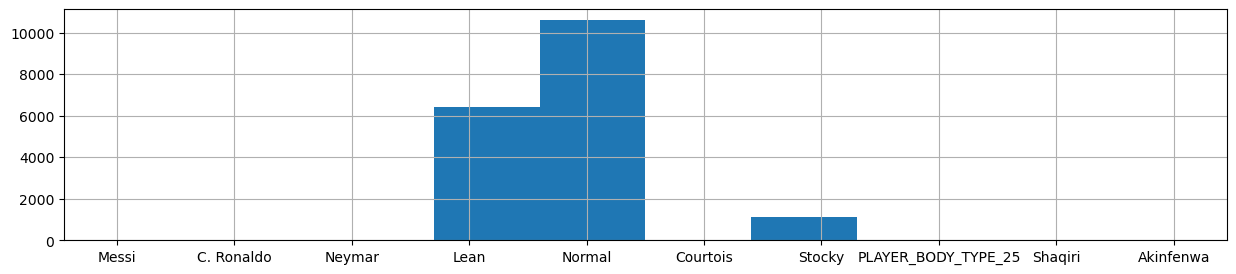

In [6]:
fifa['Body Type'].hist(figsize=[15,3])

Body Type has some unrelated values. We'll replace them with Normal

In [7]:
fifa['Work Rate'].unique()

array(['Medium/ Medium', 'High/ Low', 'High/ Medium', 'High/ High',
       'Medium/ High', 'Medium/ Low', 'Low/ High', 'Low/ Medium',
       'Low/ Low', nan], dtype=object)

In association football, work rate refers to the extent to which a player contributes to running and chasing in a match while not in possession of the ball.   
The first is for attack and second is for defense.  
We'll spoit this column into 2 categorical columns: attaack, defence

### Data cleaning

The above summary is exported to excel file.   
Then, manually each column is assigned:  
What to do with it:
 - take
 - drop
 - expand

How to treat it: identifier for a function that treats this column

That file then is loaded back to environment to serve as list of instructions.  



In [8]:
summ_rev = pd.read_excel('summary_reviewed.xlsx')
summ_rev

,column name,data type,non-null values,non-null values %,↓unique values↓,example,feature type,todo,how
0,ID,int64,18207,100.000000,18207,246165,index,take,asis
1,Photo,object,18207,100.000000,18207,https://cdn.sofifa.org/players/4/19/246165.png,meta,drop,NaN
2,Name,object,18207,100.000000,17194,J. Sinisterra,meta,drop,NaN
3,Joined,object,16654,91.470314,1736,"Oct 5, 2018",meta,drop,NaN
4,Special,int64,18207,100.000000,1422,1430,continious,take,asis
5,Release Clause,object,16643,91.409897,1244,€850K,meta,drop,NaN
6,Club Logo,object,18207,100.000000,679,https://cdn.sofifa.org/teams/2/light/110395.png,meta,drop,NaN
7,Club,object,17966,98.676333,651,Club Atlético Lanús,categ,drop,NaN
8,Value,object,18207,100.000000,217,€400K,int,take,money
9,Flag,object,18207,100.000000,164,https://cdn.sofifa.org/flags/56.png,meta,drop,NaN


Prepare columns to drop

In [9]:
drop = summ_rev['column name'][ summ_rev.todo == "drop" ].values
drop

array(['Photo', 'Name', 'Joined', 'Release Clause', 'Club Logo', 'Club',
       'Flag', 'Nationality', 'Jersey Number', 'Contract Valid Until',
       'Position', 'Real Face'], dtype=object)

Define utility functions and vars

In [10]:
feetconversions = [30.48, 2.54]

def bodyType(bt):
  ok = ['Lean', 'Normal', 'Stocky']
  if bt not in ok:
    bt = 'Normal'
  return bt


In [11]:

def WorkRate(r):
  t = r['Work Rate']
  if pd.isna(t):
    t = [np.nan,np.nan]  
  else:
    t = t.split("/ ")
  if len(t)==1:
    t = t + [np.nan]
  return pd.Series(t,index = ["Attack", "Defence"])

#test it:
# fifa.apply( WorkRate, axis =1, result_type='expand')

Prepare mappings for parsers and expanders

In [12]:
parsers = {
  # €850K  -> 850000
 'money':lambda v:eval(str(v).replace("€","").replace("K","*1000").replace("M","*1000000"))if pd.notna(v) else v , # quick and dirty, not very secure
  # 56+2   -> 56
 'score':lambda v:int(float(str(v).split("+")[0])) if pd.notna(v) else v , 
  # 154lbs -> 154
 'lbs':lambda v:int(str(v).replace("lbs","")) if pd.notna(v) else v , 
  # 5'8    -> 177.8 [cm]
 'feetInch':lambda v:pd.Series(map(int, v.split("'"))).dot(feetconversions)if pd.notna(v) else v , 
  # replace anything other than ['Lean', 'Normal', 'Stocky'] with 'Normal'
 'bodyType':lambda v: bodyType(v) if pd.notna(v) else v ,
  # verbatim: 258 -> 258
 'asis':lambda v:v}

parsers

{'money': <function __main__.<lambda>(v)>,
 'score': <function __main__.<lambda>(v)>,
 'lbs': <function __main__.<lambda>(v)>,
 'feetInch': <function __main__.<lambda>(v)>,
 'bodyType': <function __main__.<lambda>(v)>,
 'asis': <function __main__.<lambda>(v)>}

In [13]:
expanders = {
  # High/ Medium -> 2 columns: High, Medium
 'WorkRate': WorkRate ,
 }

expanders

{'WorkRate': <function __main__.WorkRate(r)>}

Mapping the columns

In [14]:
# perform dropping of unneeded columns

fifa.drop(drop, axis=1, inplace=True)

In [15]:
# perform parsing columns

for k,v in parsers.items():
  cols = summ_rev['column name'][ summ_rev.how == k ].values
  fifa[cols]= fifa[cols].map(v)


In [16]:
# perform expanding columns

for k,v in expanders.items():
  cols = summ_rev['column name'][ summ_rev.how == k ].values
  newcols = fifa.apply( v, axis=1, result_type='expand')
  fifa[newcols.columns] = newcols
# drop original column
fifa.drop(cols, axis =1, inplace=True)
  #fifa[cols]= fifa[cols].map(v)

In [17]:
summary(fifa,3);

The Dataframe has: 
 76 columns overall 
 18207 rows overall


,column name,data type,non-null values,↓non-null values %↓,unique values,example
0,ID,int64,18207,100.00%,18207,229862
2,Overall,int64,18207,100.00%,48,70
3,Potential,int64,18207,100.00%,47,81
4,Value,float64,18207,100.00%,217,3000000.0
5,Wage,int64,18207,100.00%,144,5000
6,Special,int64,18207,100.00%,1422,1706
1,Age,int64,18207,100.00%,29,21
50,Acceleration,float64,18159,99.74%,86,65.0
56,Jumping,float64,18159,99.74%,74,46.0
55,ShotPower,float64,18159,99.74%,92,68.0


### Data filling

In [18]:
fifa = fifa.ffill() 

In [19]:
summary(fifa);

The Dataframe has: 
 76 columns overall 
 18207 rows overall


,column name,data type,non-null values,non-null values %,↓unique values↓,example
0,ID,int64,18207,100.00%,18207,229692
6,Special,int64,18207,100.00%,1422,1214
4,Value,float64,18207,100.00%,217,1200000.0
5,Wage,int64,18207,100.00%,144,8000
45,Dribbling,float64,18207,100.00%,94,22.0
62,Positioning,float64,18207,100.00%,94,20.0
41,Finishing,float64,18207,100.00%,93,16.0
66,Marking,float64,18207,100.00%,92,22.0
55,ShotPower,float64,18207,100.00%,92,25.0
59,LongShots,float64,18207,100.00%,92,14.0


## 2.  The purpose of this LAB 
Is to find players that belongs to the group of players with top 10 salaries.  
Decide about the type of the feature defined in each column (categorical, numerical, binary).  
Choose 5 more promising feature for clustering to define if 10 players with biggest salary belong to the same cluster   
 
| Column name | Feature type | Way to manage a feature | Example before and after the feature transformation |
| ----------- | ------------ | ----------------------- | --------------------------------------------------- |
|             |              |                         |                                                     |



## 3. Use Spark ML library 
To prepare the feature to find clusters.
 


## 4.  Discover the number of clusters With largest Silhouette. 
For this number of clusters create a result table (the number of rows as a number of clusters):

| Clusters ID | The number of players from the 10 players with biggest salary<br> |
| ----------- | ----------------------------------------------------------------- |
|             |                                                                   |



## 5.  Use PCA to reduce the dimensions of feature vector. 
Is it more helpful for clustering? Fill following table for applying PCA with
5, 4, and 3 features.

| Clusters ID | The number of players from the 10 players with biggest salary<br> |
| ----------- | ----------------------------------------------------------------- |
|             |                                                                   |


## 6.  Perform task 6 with reduction to two features only. 
Draw 2D plot of clusters and top 10 players with biggest salary.
